# Μοντελοποίηση Μη Γραμμικού Κινδύνου Αθέτησης Πιστώσεων με Splines Παλινδρόμησης

## Σύνοψη για Στελέχη

Μια ομάδα διαχείρισης κινδύνου μιας τράπεζας λιανικής χρειάζεται να γνωρίζει *πού* ο κίνδυνος αθέτησης γίνεται μη γραμμικός πριν δεσμευτεί σε μια παραγωγική κάρτα βαθμολόγησης (scorecard). Αντί να ομαδοποιεί εκ των προτέρων κάθε χαρακτηριστικό στο χέρι, η ομάδα προσαρμόζει ένα **γενικευμένο προσθετικό μοντέλο** με το `PROC GAM`: κάθε χαρακτηριστικό του δανειολήπτη εισέρχεται ως κυβική εξομαλυντική spline, ώστε οι σχέσεις κατωφλίου και σχήματος U να εκτιμώνται απευθείας από τα δεδομένα στην κλίμακα logit. Σε ένα σκοπίμως δυσμενές συνθετικό χαρτοφυλάκιο 100 δανείων (39% σε αθέτηση), το προσθετικό μοντέλο spline μειώνει την απόκλιση (deviance) από 133.75 (μόνο σταθερός όρος) σε 61.69 — μια πτώση 72.06 — για ένα AIC μοντέλου 81.69. Η προσαρμοσμένη εξομάλυνση του λόγου χρέους προς εισόδημα φέρει τον μεγαλύτερο συντελεστή (4.34), και η ομαδοποίηση του ακατέργαστου αποτελέσματος επιβεβαιώνει τη σχεδιασμένη δομή: ο κίνδυνος αθέτησης έχει έντονο **σχήμα U ως προς την ηλικία** (66.7% μεταξύ των νεότερων δανειοληπτών, 4.8% στη μέση ηλικία, 86.4% μεταξύ των μεγαλύτερων) και αυξάνεται με τη μόχλευση.

## Πηγές Δεδομένων

| Σύνολο δεδομένων | Γραμμές | Ρόλος | Βασικές μεταβλητές | Περιγραφή |
|---------|------|------|---------------|-------------|
| `loans` | 100 | Είσοδος μοντελοποίησης | `default` (στόχος 0/1), `age`, `dti` (χρέος προς εισόδημα), `utilization` (χρήση ανακυκλούμενης πίστωσης) | Συνθετικές αιτήσεις δανείων λιανικής. Ο πραγματικός λογάριθμος πιθανοτήτων (log-odds) αθέτησης κατασκευάζεται με σκόπιμες μη γραμμικότητες — μια επίδραση ηλικίας σχήματος U και αρθρώσεις (hinges) κατωφλίου στον λόγο χρέους προς εισόδημα και στη χρήση — και στη συνέχεια δειγματοληπτείται κατά Bernoulli. Δημιουργείται εσωτερικά με `call streaminit(20260531)` και `rand()`· χωρίς εξωτερικά αρχεία. |

Αυτό το περιβάλλον εκτελείται χωρίς άδεια, οπότε η έξοδος περιορίζεται σε 100 παρατηρήσεις. Το σενάριο είναι διαστασιολογημένο σε αυτό το όριο: το σήμα γίνεται αρκετά ισχυρό ώστε ένα προσθετικό μοντέλο spline τριών όρων να μπορεί να ανακτήσει τα σχήματα από 100 δάνεια.

# Γιατί splines για τον πιστωτικό κίνδυνο

Οι παραδοσιακές κάρτες βαθμολόγησης στηρίζονται στη λογιστική παλινδρόμηση με χειροκίνητα ομαδοποιημένες μεταβλητές (weight-of-evidence / information-value). Αυτό λειτουργεί, αλλά αναγκάζει τον αναλυτή να *μαντεύει* πού βρίσκονται τα κατώφλια κινδύνου και η καμπυλότητα. Ένα **γενικευμένο προσθετικό μοντέλο (GAM)** αντικαθιστά κάθε γραμμικό όρο με μια εξομαλυντική συνάρτηση — εδώ μια κυβική εξομαλυντική spline με τρεις βαθμούς ελευθερίας — ώστε το σχήμα της καμπύλης να εκτιμάται αντί να υποτίθεται. Το `PROC GAM` προσαρμόζει αυτές τις εξομαλύνσεις στην κλίμακα logit για έναν δυαδικό στόχο, ακριβώς το πλαίσιο ενός μοντέλου πιθανότητας αθέτησης.

Σε αυτό το notebook παίζουμε τον ρόλο μιας ομάδας διαχείρισης κινδύνου τράπεζας λιανικής. Εμείς:

1. Δημιουργούμε ένα συνθετικό χαρτοφυλάκιο δανείων του οποίου η **πραγματική** πιθανότητα αθέτησης είναι γνήσια μη γραμμική (μια επίδραση ηλικίας σχήματος U και επιδράσεις κατωφλίου στον λόγο χρέους προς εισόδημα και στη χρήση).
2. Προσαρμόζουμε ένα διωνυμικό/logit προσθετικό μοντέλο spline και διαβάζουμε την απόκλισή του, το AIC και τους συντελεστές ανά εξομάλυνση.
3. Επιβεβαιώνουμε τα ανακτηθέντα σχήματα ομαδοποιώντας το ακατέργαστο αποτέλεσμα αθέτησης και σχεδιάζοντάς το με το `PROC SGPLOT`.

Τίποτα εδώ δεν απαιτεί εξωτερικά δεδομένα ή σύνδεση δικτύου.

## Βήμα 1 - Δημιουργία ενός συνθετικού χαρτοφυλακίου δανείων

Προσομοιώνουμε 100 αιτήσεις δανείων. Κάθε δανειολήπτης έχει τρία χαρακτηριστικά. Ο **λογάριθμος πιθανοτήτων (log-odds) αθέτησης** κατασκευάζεται από σκόπιμα μη γραμμικές συνιστώσες ώστε να έχουμε μια γνωστή αλήθεια εδάφους (ground truth) την οποία το μοντέλο spline θα ανακτήσει:

- **Ηλικία** - ένα σχήμα U: ο κίνδυνος αθέτησης είναι αυξημένος για πολύ νέους και πολύ μεγάλους δανειολήπτες και χαμηλότερος στη μέση ηλικία. Το κωδικοποιούμε ως έναν τετραγωνικό, κεντραρισμένο όρο ηλικίας.
- **DTI** - μια επίδραση κατωφλίου: ελάχιστη επίπτωση μέχρι ο λόγος χρέους προς εισόδημα να ξεπεράσει το ~0.35, οπότε ο κίνδυνος ανεβαίνει (μια μονόπλευρη άρθρωση).
- **Utilization** - μια δεύτερη άρθρωση στο ~0.60 της ανακυκλούμενης πιστωτικής γραμμής.

Η δυαδική σημαία `default` αντλείται στη συνέχεια από μια κατανομή Bernoulli με αυτή την πιθανότητα. Ο σταθερός όρος ορίζεται αρκετά χαμηλά ώστε οι σχεδιασμένες μη γραμμικότητες, και όχι μια υψηλή βασική τιμή, να οδηγούν τις αθετήσεις — πρόκειται για ένα σκοπίμως δυσμενές χαρτοφυλάκιο υψηλού κινδύνου, επιλεγμένο ώστε τα σχήματα να είναι ορατά σε μόλις 100 δάνεια.

In [1]:
ΔΕΔΟΜΕΝΑ loans;
   CALL streaminit(20260531);

   ΕΠΑΝΑΛΗΨΗ id = 1 ΕΩΣ 100;
      /* ---- borrower features ---- */
      AGE         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 years  */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* debt-to-income  */
      utilization = rand("UNIFORM");               /* 0 .. 1 of limit */

      /* ---- TRUE nonlinear log-odds of default ---- */
      age_c    = (AGE - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* U-shaped        */
      eta_dti  = 8.0 * MAX(dti - 0.35, 0);         /* threshold hinge */
      eta_util = 2.5 * MAX(utilization - 0.60, 0); /* threshold hinge */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = LOGISTIC(eta);
      default = rand("BERNOULLI", p_true);

      ΑΦΑΙΡΕΣΗ age_c eta_age eta_dti eta_util eta p_true;
      ΕΞΟΔΟΣ;
   ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

TITLE "Σύνοψη συνθετικού χαρτοφυλακίου δανείων";
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=loans n mean MIN MAX maxdec=3;
   ΜΕΤΑΒΛΗΤΗ default AGE dti utilization;
   ΕΤΙΚΕΤΑ default="Αθέτηση" AGE="Ηλικία" dti="Χρέος προς εισόδημα" utilization="Χρήση πίστωσης";
ΕΚΤΕΛΕΣΗ;
TITLE;

                                        Σύνοψη συνθετικού χαρτοφυλακίου δανείων                                         

                                                  The MEANS Procedure

 Variable     Label                                        N           Mean     Minimum     Maximum
 --------------------------------------------------------------------------------------------------
 default      Αθέτηση                                    100          0.390       0.000       1.000
 AGE          Ηλικία                                     100         44.993      18.342      69.646
 dti          Χρέος προς εισόδημα                        100          0.312       0.059       0.590
 utilization  Χρήση πίστωσης                             100          0.548       0.012       0.988
 --------------------------------------------------------------------------------------------------




NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: Option TITLE changed to Σύνοψη συνθετικού χαρτοφυλακίου δανείων.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Η σύνοψη του `PROC MEANS` επιβεβαιώνει το χαρτοφυλάκιο: ένα συνολικό ποσοστό αθέτησης **39%** (ένα καταπονημένο, υψηλού κινδύνου βιβλίο), με την ηλικία να εκτείνεται από 18 έως 70, τον λόγο χρέους προς εισόδημα κατά μέσο όρο στο 0.31 και τη χρήση κατά μέσο όρο στο 0.55 σε όλο το εύρος 0-1. Με τα δεδομένα στα χέρια μας μπορούμε να προσαρμόσουμε το μοντέλο.

## Βήμα 2 - Προσαρμογή του προσθετικού μοντέλου spline

Η δήλωση `MODEL` ονομάζει τη δυαδική απόκριση και περικλείει κάθε προβλέπτη σε `spline(var, df=3)`, ζητώντας μια κυβική εξομαλυντική spline με τρεις βαθμούς ελευθερίας η καθεμία. Οι επιλογές:

- `event='1'` - μοντελοποίηση της πιθανότητας του γεγονότος *αθέτησης*, όχι του μη γεγονότος.
- `dist=binomial` - ένας στόχος 0/1 προσαρμοσμένος στην κλίμακα logit, η φυσική επιλογή για μια πιθανότητα αθέτησης.

Το `PROC GAM` αναφέρει την **απόκλιση (deviance)** και το **AIC** του μοντέλου, έναν συντελεστή για κάθε όρο εξομάλυνσης, και έναν πίνακα μοντέλου εξομάλυνσης που παραθέτει τους βαθμούς ελευθερίας που δαπανώνται ανά συνιστώσα.

In [2]:
TITLE "Γενικευμένο προσθετικό λογιστικό μοντέλο αθέτησης δανείων";

ΔΙΑΔΙΚΑΣΙΑ gam ΔΕΔΟΜΕΝΑ=loans;
   ΜΟΝΤΕΛΟ default(EVENT="1") = SPLINE(AGE,         df=3)
                              SPLINE(dti,         df=3)
                              SPLINE(utilization, df=3)
                              / DIST=binomial;
ΕΚΤΕΛΕΣΗ;

TITLE;

                               Γενικευμένο προσθετικό λογιστικό μοντέλο αθέτησης δανείων                                


                                                   The GAM Procedure                                                    

Model Information
Response Variable     default
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF
Spline(


NOTE: Option TITLE changed to Γενικευμένο προσθετικό λογιστικό μοντέλο αθέτησης δανείων.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


Η προσαρμογή είναι ισχυρή. Η **μηδενική απόκλιση (null deviance)** των 133.75 (ένα μοντέλο μόνο με σταθερό όρο) πέφτει σε μια υπολειπόμενη **απόκλιση 61.69** μόλις προστεθούν οι τρεις εξομαλύνσεις — μια μείωση 72.06 — και το **AIC του μοντέλου είναι 81.69**. Μεταξύ των όρων εξομάλυνσης, η **spline του λόγου χρέους προς εισόδημα φέρει τον μεγαλύτερο συντελεστή (4.34)**, μπροστά από τις εξομαλύνσεις ηλικίας και χρήσης, αναγνωρίζοντας τη μόχλευση ως τον κυρίαρχο παράγοντα του προσαρμοσμένου log-odds. Κάθε εξομάλυνση δαπανά τρεις βαθμούς ελευθερίας, όπως ζητήθηκε. Το μοντέλο ανακάλυψε ότι αυτές οι σχέσεις είναι μη γραμμικές χωρίς να ορίσουμε ούτε μία ομάδα (bin) ή πολυωνυμικό όρο.

## Βήμα 3 - Επιβεβαίωση των ανακτηθέντων σχημάτων

Μια προσαρμοσμένη εξομάλυνση είναι πειστική μόνο αν ταιριάζει με τα ακατέργαστα δεδομένα. Ομαδοποιούμε κάθε δανειολήπτη κατά ηλικία και κατά λόγο χρέους προς εισόδημα, υπολογίζουμε το πραγματοποιηθέν ποσοστό αθέτησης σε κάθε ζώνη με το `PROC MEANS`, και το σχεδιάζουμε με το `PROC SGPLOT`. Αν το μοντέλο spline λέει την αλήθεια, το ομαδοποιημένο αποτέλεσμα θα πρέπει να ιχνηλατεί το ίδιο σχήμα U και κατώφλι που προσάρμοσε το μοντέλο.

In [3]:
ΔΕΔΟΜΕΝΑ binned;
   ΟΡΙΣΜΟΣ loans;
   LENGTH dti_band $9 age_band $5;

   ΕΑΝ      dti < 0.20 ΤΟΤΕ dti_band = "0.00-0.20";
   ΑΛΛΙΩΣ ΕΑΝ dti < 0.30 ΤΟΤΕ dti_band = "0.20-0.30";
   ΑΛΛΙΩΣ ΕΑΝ dti < 0.40 ΤΟΤΕ dti_band = "0.30-0.40";
   ΑΛΛΙΩΣ ΕΑΝ dti < 0.50 ΤΟΤΕ dti_band = "0.40-0.50";
   ΑΛΛΙΩΣ                    dti_band = "0.50+";

   ΕΑΝ      AGE < 30 ΤΟΤΕ age_band = "18-30";
   ΑΛΛΙΩΣ ΕΑΝ AGE < 40 ΤΟΤΕ age_band = "30-40";
   ΑΛΛΙΩΣ ΕΑΝ AGE < 50 ΤΟΤΕ age_band = "40-50";
   ΑΛΛΙΩΣ ΕΑΝ AGE < 60 ΤΟΤΕ age_band = "50-60";
   ΑΛΛΙΩΣ                  age_band = "60-70";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=binned NWAY NOPRINT;
   ΚΛΑΣΗ age_band;
   ΜΕΤΑΒΛΗΤΗ default;
   ΕΞΟΔΟΣ out=age_rate(ΑΦΑΙΡΕΣΗ=_type_ _freq_)
          n=n mean(default)=def_rate;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=binned NWAY NOPRINT;
   ΚΛΑΣΗ dti_band;
   ΜΕΤΑΒΛΗΤΗ default;
   ΕΞΟΔΟΣ out=dti_rate(ΑΦΑΙΡΕΣΗ=_type_ _freq_)
          n=n mean(default)=def_rate;
ΕΚΤΕΛΕΣΗ;

TITLE "Ποσοστό αθέτησης ανά ζώνη ηλικίας";
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=age_rate noobs ΕΤΙΚΕΤΑ;
   ΜΕΤΑΒΛΗΤΗ age_band n def_rate;
   ΕΤΙΚΕΤΑ age_band="Ζώνη ηλικίας" n="Λογαριασμοί" def_rate="Ποσοστό αθέτησης";
   ΜΟΡΦΗ def_rate percent8.1;
ΕΚΤΕΛΕΣΗ;

TITLE "Ποσοστό αθέτησης ανά ζώνη χρέους προς εισόδημα";
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=dti_rate noobs ΕΤΙΚΕΤΑ;
   ΜΕΤΑΒΛΗΤΗ dti_band n def_rate;
   ΕΤΙΚΕΤΑ dti_band="Ζώνη χρέους προς εισόδημα" n="Λογαριασμοί"
         def_rate="Ποσοστό αθέτησης";
   ΜΟΡΦΗ def_rate percent8.1;
ΕΚΤΕΛΕΣΗ;

                                           Ποσοστό αθέτησης ανά ζώνη ηλικίας                                            


           Ζώνη ηλικίας             Λογαριασμοί                 Ποσοστό αθέτησης
-----------------------  ----------------------  -------------------------------
18-30                                        21                            66.7%
30-40                                        19                            10.5%
40-50                                        21                             4.8%
50-60                                        17                            17.6%
60-70                                        22                            86.4%

                                     Ποσοστό αθέτησης ανά ζώνη χρέους προς εισόδημα                                     


                      Ζώνη χρέους προς εισόδημα             Λογαριασμοί                 Ποσοστό αθέτησης
-----------------------------------------------  ----------------------  --------


NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: Option TITLE changed to Ποσοστό αθέτησης ανά ζώνη ηλικίας.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: Option TITLE changed to Ποσοστό αθέτησης ανά ζώνη χρέους προς εισόδημα.
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


Οι ζώνες ηλικίας ιχνηλατούν ένα καθαρό U: **66.7%** των δανειοληπτών κάτω των 30 αθέτησαν, το ποσοστό αγγίζει τον πάτο στο **4.8%** για τη ζώνη 40-50, και στη συνέχεια ανεβαίνει ξανά στο **86.4%** για δανειολήπτες 60 ετών και άνω. Οι ζώνες του λόγου χρέους προς εισόδημα κινούνται συνολικά προς τα πάνω — από περίπου 37% στη χαμηλότερη ζώνη σε περίπου 50% πέρα από ένα DTI 0.40 — αν και με μόλις 100 δάνεια τα ποσοστά ανά ζώνη είναι θορυβώδη, γι' αυτό ακριβώς η εξομάλυνση του μοντέλου (αντί για ένα μοναδικό απότομο όριο) είναι η πιο αξιόπιστη σύνοψη. Τα γραφήματα παρακάτω καθιστούν και τα δύο σχήματα ορατά.

### Η επίδραση της ηλικίας έχει σχήμα U

Η σχεδίαση του πραγματοποιηθέντος ποσοστού αθέτησης ανά ζώνη ηλικίας δείχνει την καμπυλότητα που ανέκτησε η spline: υψηλός κίνδυνος και στα δύο άκρα του εύρους ηλικίας, μια βαθιά κοιλάδα στη μέση ηλικία.

                                     Ποσοστό αθέτησης ανά ζώνη χρέους προς εισόδημα                                     




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


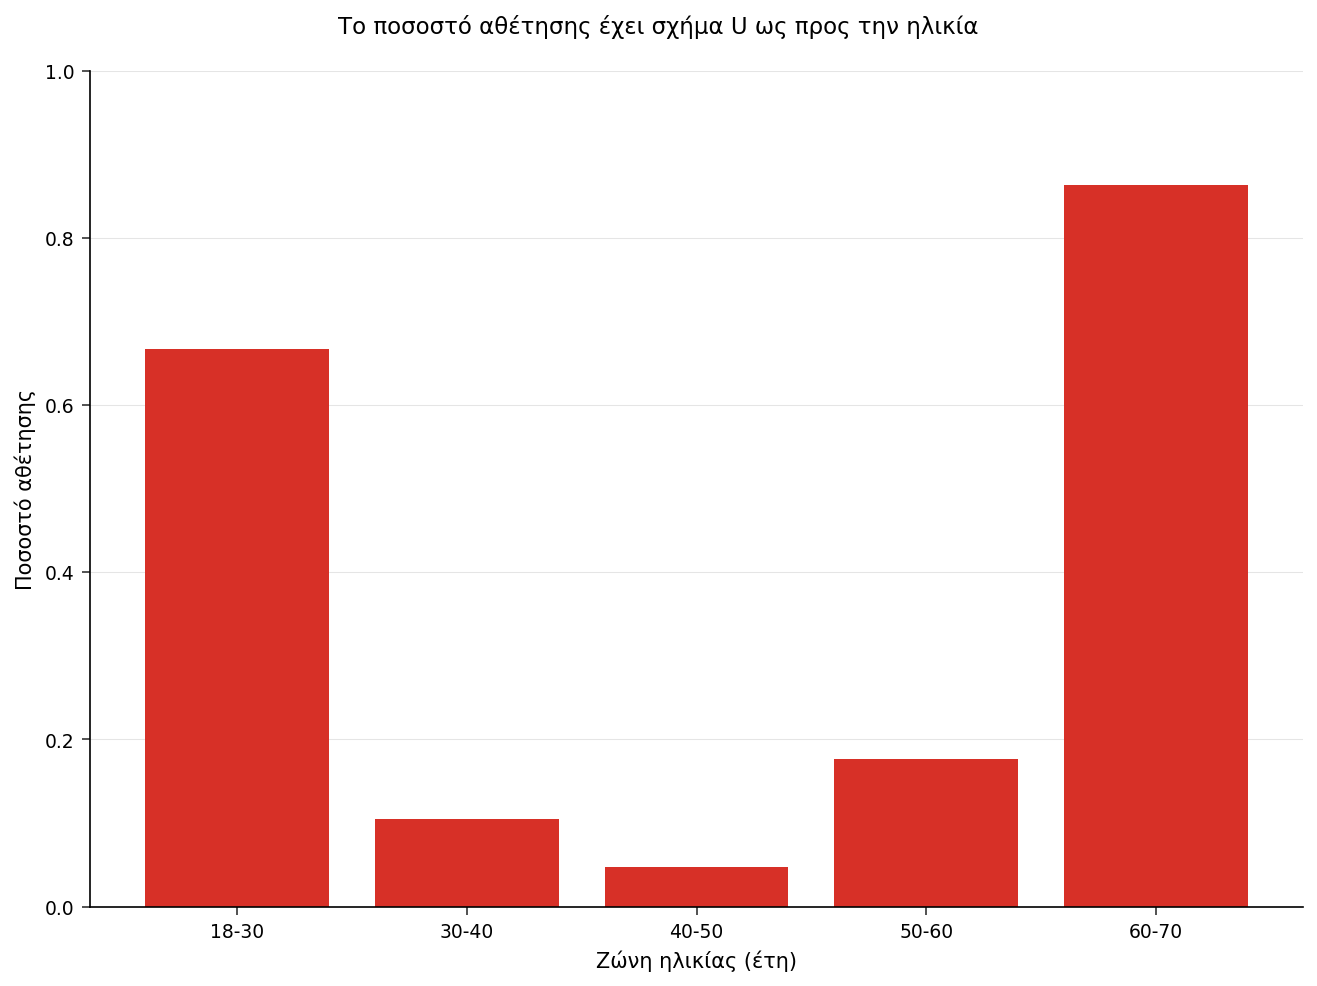

In [4]:
ODS GRAPHICS ON;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=age_rate noautolegend;
   TITLE "Το ποσοστό αθέτησης έχει σχήμα U ως προς την ηλικία";
   VBAR age_band / RESPONSE=def_rate fillattrs=(color=cxd73027);
   YAXIS ΕΤΙΚΕΤΑ="Ποσοστό αθέτησης" VALUES=(0 ΕΩΣ 1 ΚΑΤΑ 0.2) grid;
   XAXIS ΕΤΙΚΕΤΑ="Ζώνη ηλικίας (έτη)";
ΕΚΤΕΛΕΣΗ;

TITLE;
ODS GRAPHICS OFF;

### Ο κίνδυνος αυξάνεται με τη μόχλευση

Οι ζώνες του λόγου χρέους προς εισόδημα εμφανίζουν ανοδική τάση — οι πιο μοχλευμένοι δανειολήπτες αθετούν συχνότερα — σε συμφωνία με την κυρίαρχη εξομάλυνση DTI στο μοντέλο. Οι μεσαίες ζώνες είναι θορυβώδεις σε αυτό το μέγεθος δείγματος, υπογραμμίζοντας γιατί η προσαρμοσμένη spline είναι πιο σταθερός οδηγός από οποιοδήποτε μοναδικό χειροκίνητα σχεδιασμένο όριο.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


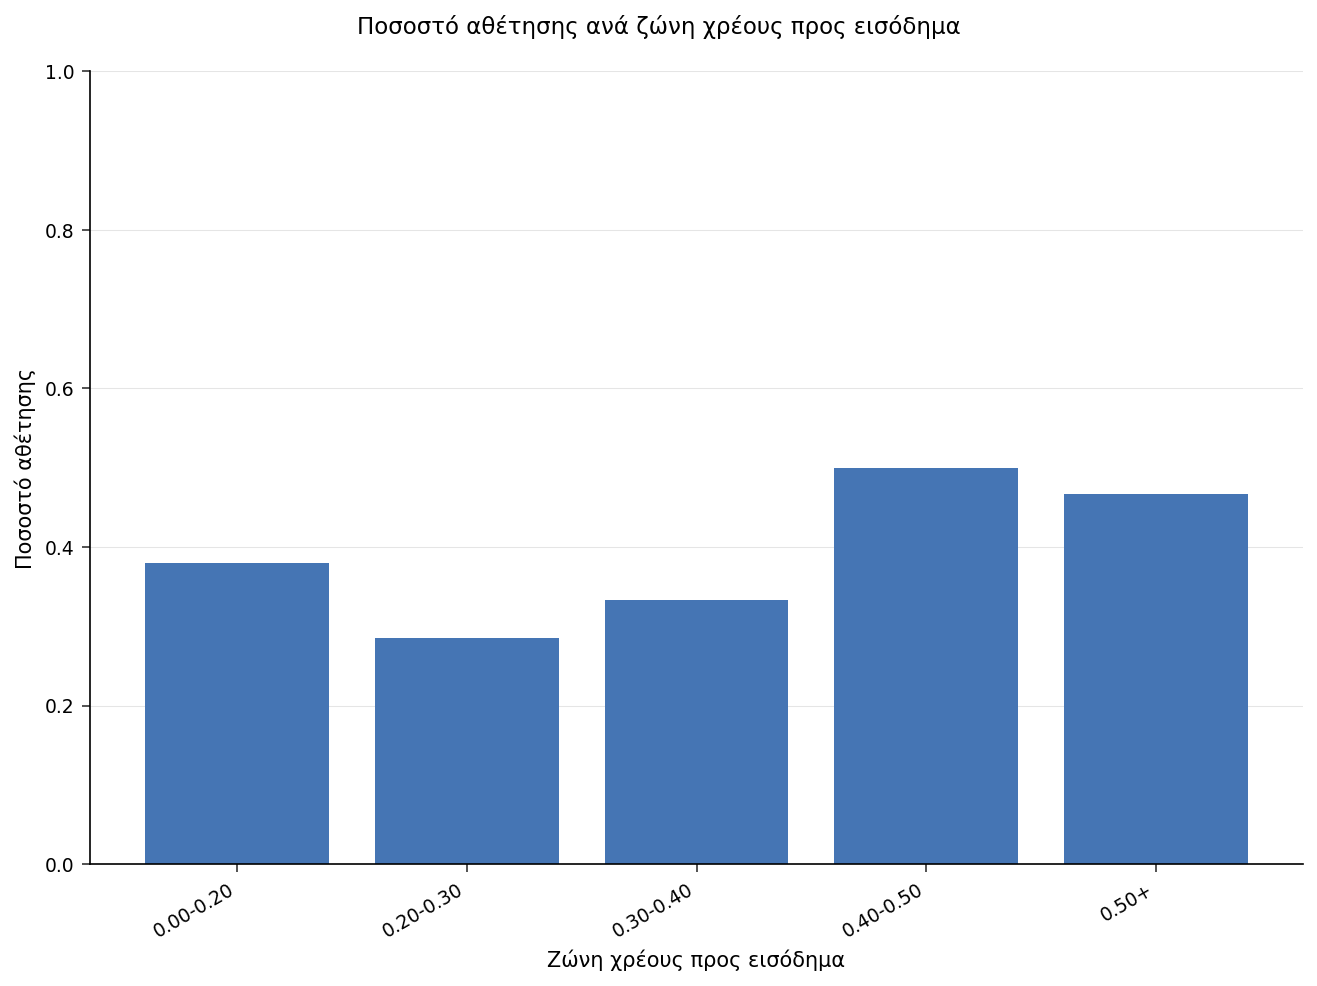

In [5]:
ODS GRAPHICS ON;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=dti_rate noautolegend;
   TITLE "Ποσοστό αθέτησης ανά ζώνη χρέους προς εισόδημα";
   VBAR dti_band / RESPONSE=def_rate fillattrs=(color=cx4575b4);
   YAXIS ΕΤΙΚΕΤΑ="Ποσοστό αθέτησης" VALUES=(0 ΕΩΣ 1 ΚΑΤΑ 0.2) grid;
   XAXIS ΕΤΙΚΕΤΑ="Ζώνη χρέους προς εισόδημα";
ΕΚΤΕΛΕΣΗ;

TITLE;
ODS GRAPHICS OFF;

## Ερμηνεία των αποτελεσμάτων

Το `PROC GAM` ανέκτησε τη μη γραμμική δομή που ενσωματώσαμε στο συνθετικό χαρτοφυλάκιο χωρίς καμία χειροκίνητη ομαδοποίηση ή πολυωνυμικούς όρους:

- **Ισχυρή συνολική προσαρμογή** - το προσθετικό μοντέλο spline οδηγεί την απόκλιση από 133.75 κάτω στο 61.69 (μια μείωση 72.06) για ένα AIC μοντέλου 81.69, σε ένα βιβλίο με βασικό ποσοστό αθέτησης 39%.
- **Η μόχλευση κυριαρχεί** - η εξομάλυνση του λόγου χρέους προς εισόδημα φέρει τον μεγαλύτερο συντελεστή (4.34) από τους τρεις όρους, επισημαίνοντας το DTI ως τον κορυφαίο παράγοντα του προσαρμοσμένου log-odds.
- **Καμπυλότητα στην ηλικία** - η ομαδοποίηση του ακατέργαστου αποτελέσματος επιβεβαιώνει ένα σχολικό U: 66.7% αθέτηση στη ζώνη κάτω των 30, μια κοιλάδα 4.8% στα 40-50, και 86.4% για τη ζώνη των 60 και άνω — το σχήμα που μια κυβική spline συλλαμβάνει φυσικά αλλά ένας μοναδικός γραμμικός όρος ηλικίας θα αστοχούσε εντελώς.
- **Έντιμο ως προς τον θόρυβο** - στα 100 δάνεια τα ποσοστά του λόγου χρέους προς εισόδημα ανά ζώνη ταλαντεύονται, που είναι ακριβώς η περίπτωση όπου μια εξομαλυμένη εκτίμηση υπερτερεί ενός απότομου χειροκίνητα επιλεγμένου ορίου.

**Γιατί αυτό έχει σημασία για τον τραπεζικό τομέα:** οι προσθετικές splines δίνουν σε μια ομάδα κινδύνου έναν γρήγορο, αυτόματο τρόπο να εντοπίζει πού μια σχέση είναι γνήσια μη γραμμική πριν δεσμευτεί σε μια παραγωγική κάρτα βαθμολόγησης. Οι προσαρμοσμένες εξομαλύνσεις είναι άμεσα ερμηνεύσιμες ως καμπύλες κινδύνου — ένα ασφάλιστρο νεαρής-και-μεγάλης ηλικίας, μια ράμπα μόχλευσης — και η απόκλιση και το AIC ποσοτικοποιούν πόσο αξίζει αυτή η ευελιξία έναντι ενός επίπεδου γραμμικού μοντέλου.